In [1]:
import sys
from pathlib import Path
import importlib

%load_ext autoreload
%autoreload 2

current = Path.cwd()

if (current / "ultrasound_tracker").exists():
    PROJECT_ROOT = current
elif (current.parent / "ultrasound_tracker").exists():
    PROJECT_ROOT = current.parent
else:
    raise FileNotFoundError("Could not find ultrasound_tracker folder")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("PROJECT_ROOT =", PROJECT_ROOT)

PROJECT_ROOT = /Users/grosbedou/PycharmProjects/NDORMS


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

import ultrasound_tracker.roi as roi
import ultrasound_tracker.geometry as geom
import ultrasound_tracker.utils as ut

roi = importlib.reload(roi)
geom = importlib.reload(geom)
ut = importlib.reload(ut)

print("ROI file:", roi.__file__)
print("Geometry file:", geom.__file__)
print("Utils file:", ut.__file__)

ROI file: /Users/grosbedou/PycharmProjects/NDORMS/ultrasound_tracker/roi.py
Geometry file: /Users/grosbedou/PycharmProjects/NDORMS/ultrasound_tracker/geometry.py
Utils file: /Users/grosbedou/PycharmProjects/NDORMS/ultrasound_tracker/utils.py


In [3]:
KALMAN_NPZ = PROJECT_ROOT / "results" / "kalman_fusion_features_arrays.npz"

loaded = np.load(KALMAN_NPZ, allow_pickle=True)

print("Loaded:", KALMAN_NPZ)
print("Keys:")
for key in loaded.files:
    print(" -", key, loaded[key].shape)

Loaded: /Users/grosbedou/PycharmProjects/NDORMS/results/kalman_fusion_features_arrays.npz
Keys:
 - frame (2667,)
 - time_s (2667,)
 - success (2667,)
 - kalman_length_px (2667,)
 - kalman_pennation_angle_deg (2667,)
 - kalman_angle_uncertainty (2667,)
 - kalman_length_uncertainty (2667,)
 - used_timtrack_measurement (2667,)
 - used_klt_prediction (2667,)
 - timtrack_length_px (2667,)
 - timtrack_pennation_angle_deg (2667,)
 - klt_length_px (2667,)
 - klt_pennation_angle_deg (2667,)
 - klt_n_points (2667,)


In [4]:
frame_arr = loaded["frame"]
time_arr = loaded["time_s"]
success_arr = loaded["success"]

kalman_length = loaded["kalman_length_px"]
kalman_pennation = loaded["kalman_pennation_angle_deg"]

kalman_angle_uncertainty = loaded["kalman_angle_uncertainty"]
kalman_length_uncertainty = loaded["kalman_length_uncertainty"]

used_timtrack = loaded["used_timtrack_measurement"]
used_klt = loaded["used_klt_prediction"]

print("Number of frames:", len(frame_arr))
print("Kalman success rate:", 100 * np.mean(success_arr), "%")
print("Used TimTrack measurement:", 100 * np.mean(used_timtrack), "%")
print("Used KLT prediction:", 100 * np.mean(used_klt), "%")

Number of frames: 2667
Kalman success rate: 100.0 %
Used TimTrack measurement: 100.0 %
Used KLT prediction: 99.96250468691413 %


In [5]:
def describe_uncertainty(name, arr):
    arr = np.asarray(arr, dtype=np.float64)
    finite = np.isfinite(arr)

    print(f"\n{name}")
    print("  finite values:", np.sum(finite), "/", len(arr))
    print("  min:", np.nanmin(arr))
    print("  max:", np.nanmax(arr))
    print("  mean:", np.nanmean(arr))
    print("  median:", np.nanmedian(arr))
    print("  exactly zero:", np.sum(arr == 0))
    print("  below 1e-12:", np.sum(arr < 1e-12))
    print("  below 1e-6:", np.sum(arr < 1e-6))

describe_uncertainty("Angle uncertainty", kalman_angle_uncertainty)
describe_uncertainty("Length uncertainty", kalman_length_uncertainty)


Angle uncertainty
  finite values: 2667 / 2667
  min: 0.18019206821918488
  max: 100.0
  mean: 0.22961809669132754
  median: 0.18019206821918488
  exactly zero: 0
  below 1e-12: 0
  below 1e-6: 0

Length uncertainty
  finite values: 2667 / 2667
  min: 0.18019206821918488
  max: 100.0
  mean: 0.22961809669132754
  median: 0.18019206821918488
  exactly zero: 0
  below 1e-12: 0
  below 1e-6: 0


In [6]:
mask_after_1s = (time_arr > 1.0) & success_arr

print("Frames after 1s:", np.sum(mask_after_1s))

describe_uncertainty(
    "Angle uncertainty after 1s",
    kalman_angle_uncertainty[mask_after_1s],
)

describe_uncertainty(
    "Length uncertainty after 1s",
    kalman_length_uncertainty[mask_after_1s],
)

Frames after 1s: 2633

Angle uncertainty after 1s
  finite values: 2633 / 2633
  min: 0.18019206821918488
  max: 0.4558943212032318
  mean: 0.1829254773239921
  median: 0.18019206821918488
  exactly zero: 0
  below 1e-12: 0
  below 1e-6: 0

Length uncertainty after 1s
  finite values: 2633 / 2633
  min: 0.18019206821918488
  max: 0.4558943212032318
  mean: 0.1829254773239921
  median: 0.18019206821918488
  exactly zero: 0
  below 1e-12: 0
  below 1e-6: 0


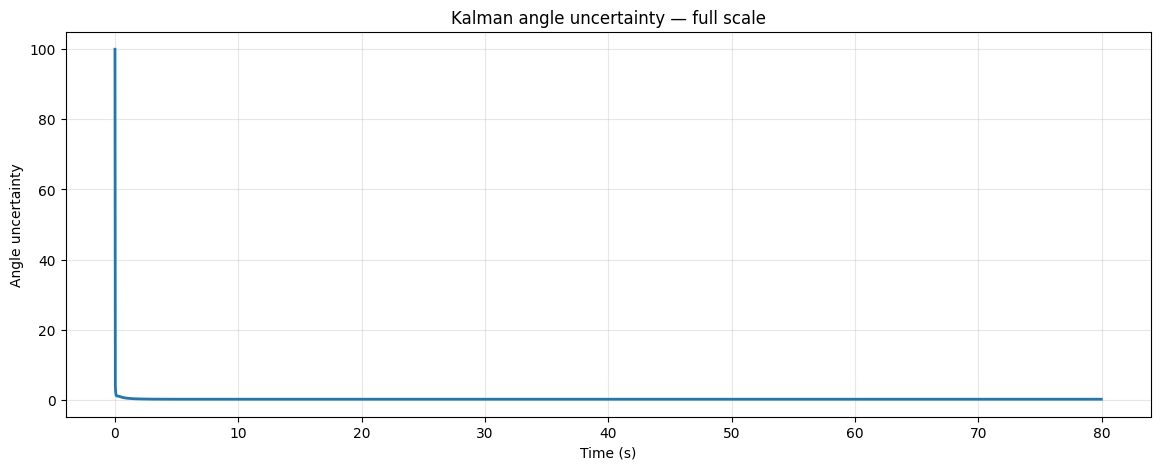

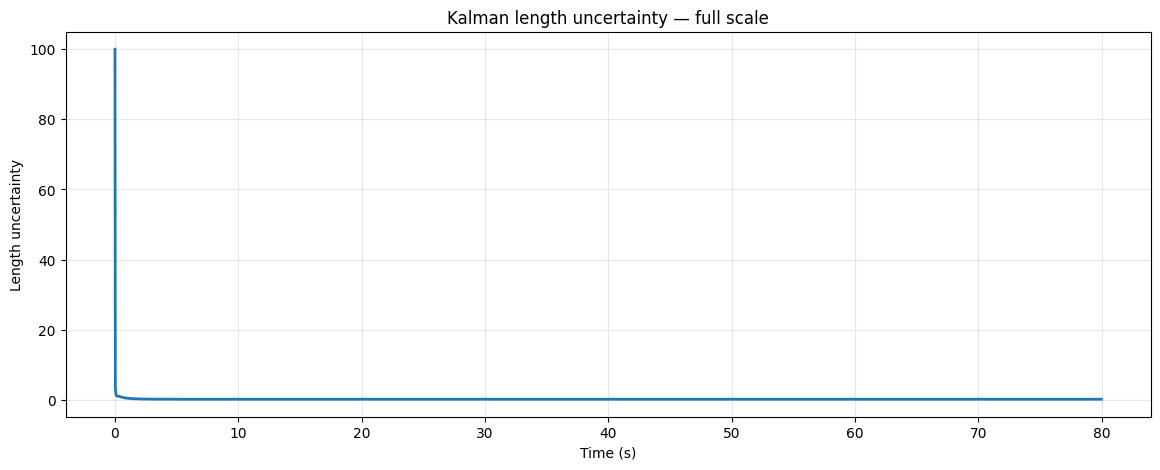

In [7]:
plt.figure(figsize=(14, 5))
plt.plot(time_arr, kalman_angle_uncertainty, "-", linewidth=2)
plt.xlabel("Time (s)")
plt.ylabel("Angle uncertainty")
plt.title("Kalman angle uncertainty — full scale")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(14, 5))
plt.plot(time_arr, kalman_length_uncertainty, "-", linewidth=2)
plt.xlabel("Time (s)")
plt.ylabel("Length uncertainty")
plt.title("Kalman length uncertainty — full scale")
plt.grid(True, alpha=0.3)
plt.show()

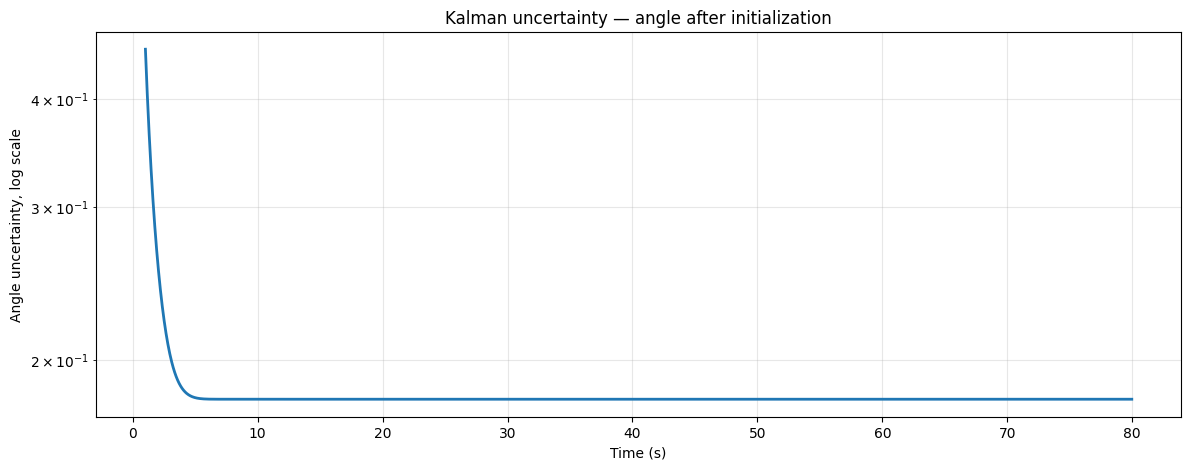

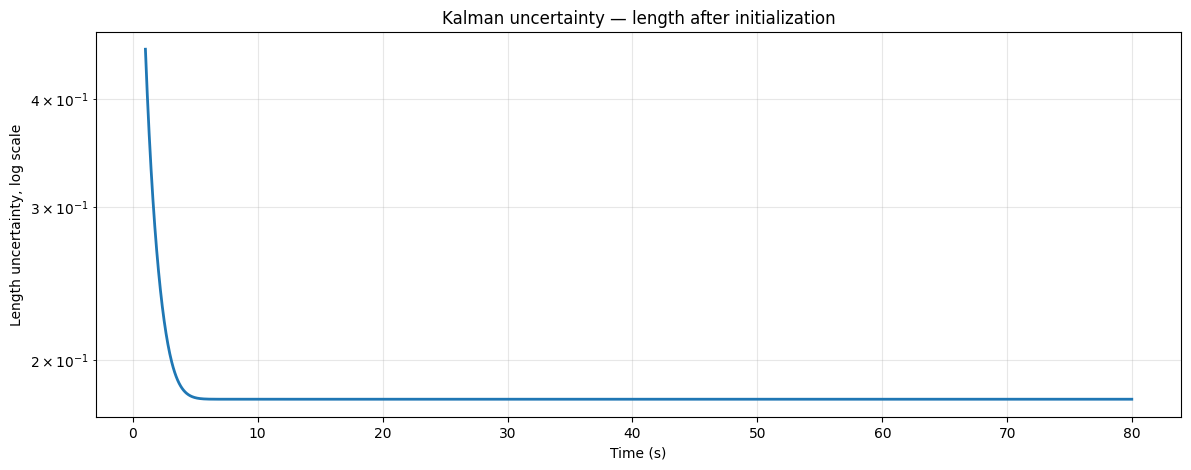

In [8]:
EPS = 1e-12

mask_log = (time_arr > 1.0) & success_arr

angle_unc_log = np.clip(kalman_angle_uncertainty[mask_log], EPS, None)
length_unc_log = np.clip(kalman_length_uncertainty[mask_log], EPS, None)
time_log = time_arr[mask_log]

plt.figure(figsize=(14, 5))
plt.semilogy(time_log, angle_unc_log, "-", linewidth=2)
plt.xlabel("Time (s)")
plt.ylabel("Angle uncertainty, log scale")
plt.title("Kalman uncertainty — angle after initialization")
plt.grid(True, alpha=0.3, which="both")
plt.show()

plt.figure(figsize=(14, 5))
plt.semilogy(time_log, length_unc_log, "-", linewidth=2)
plt.xlabel("Time (s)")
plt.ylabel("Length uncertainty, log scale")
plt.title("Kalman uncertainty — length after initialization")
plt.grid(True, alpha=0.3, which="both")
plt.show()

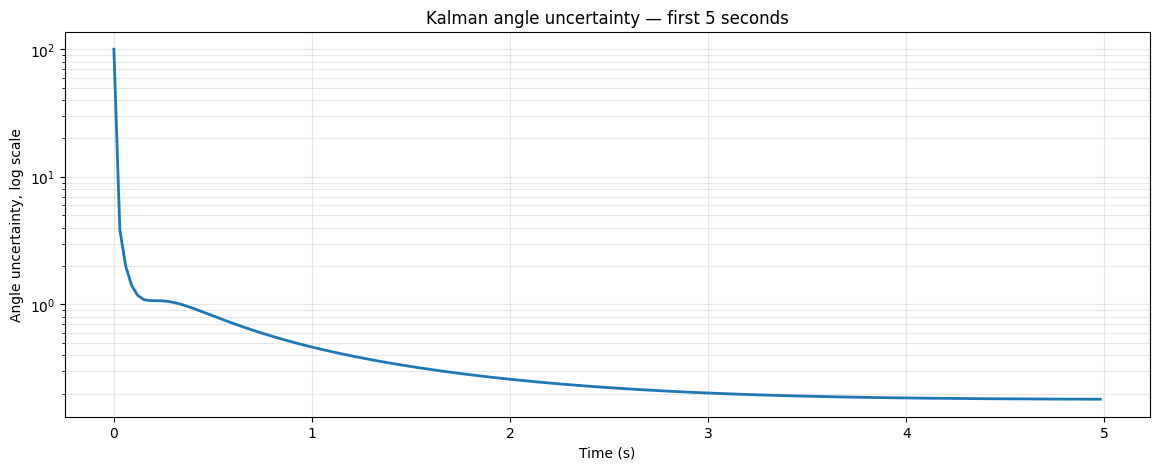

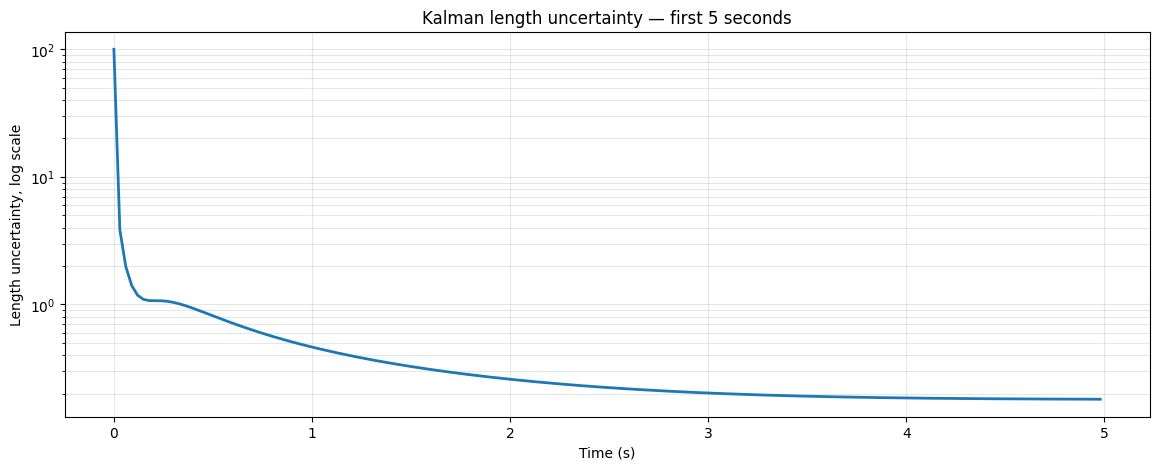

In [9]:
mask_first_5s = (time_arr <= 5.0) & success_arr

plt.figure(figsize=(14, 5))
plt.semilogy(
    time_arr[mask_first_5s],
    np.clip(kalman_angle_uncertainty[mask_first_5s], EPS, None),
    "-",
    linewidth=2,
)
plt.xlabel("Time (s)")
plt.ylabel("Angle uncertainty, log scale")
plt.title("Kalman angle uncertainty — first 5 seconds")
plt.grid(True, alpha=0.3, which="both")
plt.show()

plt.figure(figsize=(14, 5))
plt.semilogy(
    time_arr[mask_first_5s],
    np.clip(kalman_length_uncertainty[mask_first_5s], EPS, None),
    "-",
    linewidth=2,
)
plt.xlabel("Time (s)")
plt.ylabel("Length uncertainty, log scale")
plt.title("Kalman length uncertainty — first 5 seconds")
plt.grid(True, alpha=0.3, which="both")
plt.show()

In [10]:
def estimate_convergence_time(time, uncertainty, success, start_time=1.0, factor=2.0):
    """
    Estimate time when uncertainty gets below factor × steady-state median.
    Steady-state median is calculated after start_time.
    """
    time = np.asarray(time)
    uncertainty = np.asarray(uncertainty)
    success = np.asarray(success)

    mask_steady = (time > start_time) & success & np.isfinite(uncertainty)

    if np.sum(mask_steady) == 0:
        return np.nan, np.nan

    steady_median = np.nanmedian(uncertainty[mask_steady])
    threshold = factor * steady_median

    mask_reached = success & np.isfinite(uncertainty) & (uncertainty <= threshold)

    if np.sum(mask_reached) == 0:
        return np.nan, threshold

    first_idx = np.where(mask_reached)[0][0]
    return time[first_idx], threshold


angle_conv_time, angle_threshold = estimate_convergence_time(
    time_arr,
    kalman_angle_uncertainty,
    success_arr,
    start_time=1.0,
    factor=2.0,
)

length_conv_time, length_threshold = estimate_convergence_time(
    time_arr,
    kalman_length_uncertainty,
    success_arr,
    start_time=1.0,
    factor=2.0,
)

print("Angle convergence time:", angle_conv_time, "s")
print("Angle threshold:", angle_threshold)

print("Length convergence time:", length_conv_time, "s")
print("Length threshold:", length_threshold)

Angle convergence time: 1.3496896 s
Angle threshold: 0.36038414
Length convergence time: 1.3496896 s
Length threshold: 0.36038414


In [11]:
angle_initial = kalman_angle_uncertainty[success_arr][0]
length_initial = kalman_length_uncertainty[success_arr][0]

angle_after_1s_median = np.nanmedian(kalman_angle_uncertainty[mask_after_1s])
length_after_1s_median = np.nanmedian(kalman_length_uncertainty[mask_after_1s])

print("INTERPRETATION")
print("--------------")
print(f"Angle uncertainty starts around {angle_initial:.3g} and has median {angle_after_1s_median:.3g} after 1s.")
print(f"Length uncertainty starts around {length_initial:.3g} and has median {length_after_1s_median:.3g} after 1s.")

print("\nThis means:")
print("- The filter starts with high initial uncertainty.")
print("- Because TimTrack measurements are available almost every frame, the covariance collapses quickly.")
print("- It is probably not truly zero; it is just much smaller than the initial value.")
print("- If it becomes exactly zero or near machine precision, the filter is overconfident.")
print("- A larger PROCESS_NOISE or MEASUREMENT_NOISE in notebook 14 can prevent overconfidence.")

INTERPRETATION
--------------
Angle uncertainty starts around 100 and has median 0.18 after 1s.
Length uncertainty starts around 100 and has median 0.18 after 1s.

This means:
- The filter starts with high initial uncertainty.
- Because TimTrack measurements are available almost every frame, the covariance collapses quickly.
- It is probably not truly zero; it is just much smaller than the initial value.
- If it becomes exactly zero or near machine precision, the filter is overconfident.
- A larger PROCESS_NOISE or MEASUREMENT_NOISE in notebook 14 can prevent overconfidence.


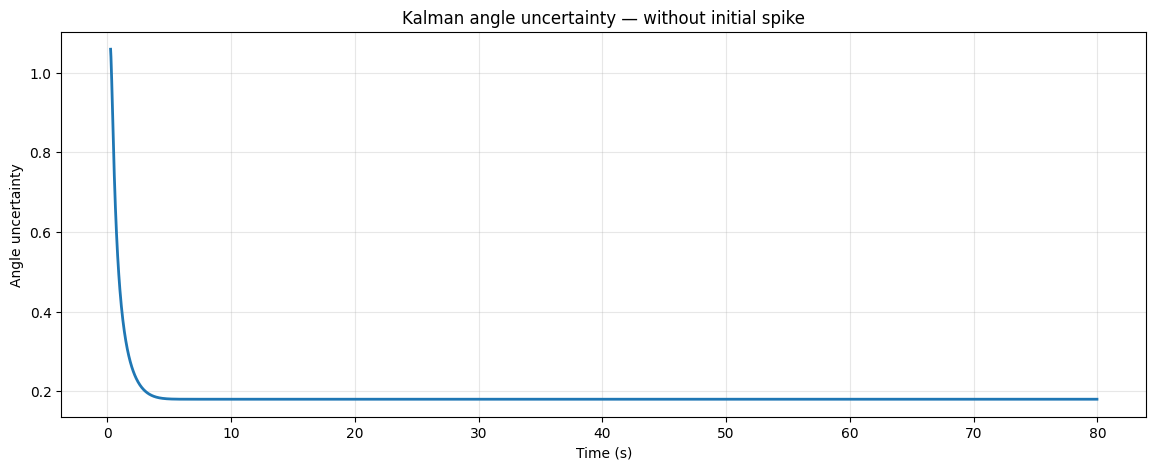

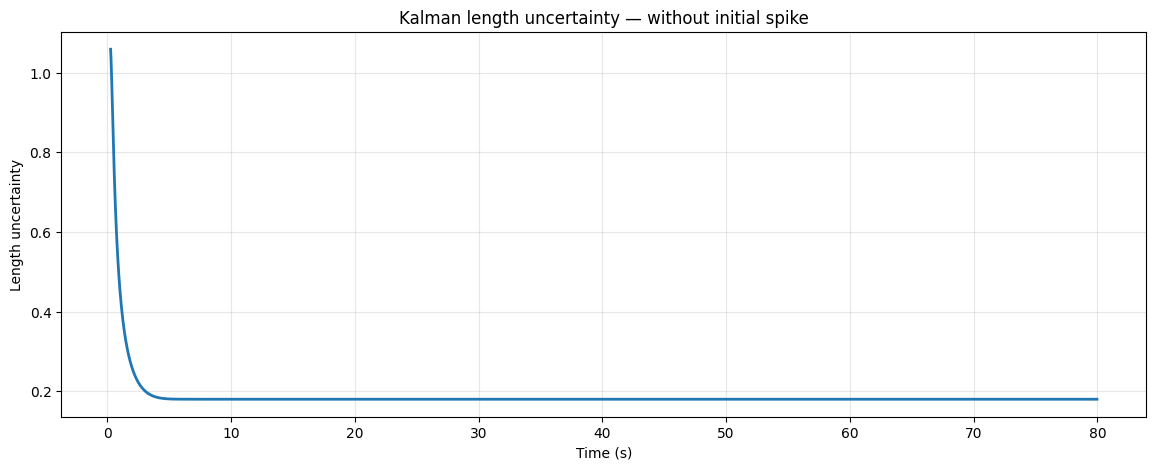

In [12]:
mask_no_initial = (time_arr > 0.25) & success_arr

plt.figure(figsize=(14, 5))
plt.plot(time_arr[mask_no_initial], kalman_angle_uncertainty[mask_no_initial], "-", linewidth=2)
plt.xlabel("Time (s)")
plt.ylabel("Angle uncertainty")
plt.title("Kalman angle uncertainty — without initial spike")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(14, 5))
plt.plot(time_arr[mask_no_initial], kalman_length_uncertainty[mask_no_initial], "-", linewidth=2)
plt.xlabel("Time (s)")
plt.ylabel("Length uncertainty")
plt.title("Kalman length uncertainty — without initial spike")
plt.grid(True, alpha=0.3)
plt.show()